Import 3 months stock market data for INFY, IOCL, HINDUNILVR and predict their future values using GRU


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

print("Libraries imported successfully.")

Libraries imported successfully.


### Loading and Inspecting Data for INFY

In [ ]:
infy_df = pd.read_csv('/content/kiocl.csv')
print('INFY DataFrame Info:')
infy_df.info()
print('\nINFY DataFrame Head:')
display(infy_df.head())

INFY DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246 entries, 0 to 245
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   DateTime  246 non-null    object 
 1   INFYEQN   246 non-null    float64
dtypes: float64(1), object(1)
memory usage: 4.0+ KB

INFY DataFrame Head:


,DateTime,INFYEQN
0,2025-06-23 00:00:00,1584.7
1,2025-06-24 00:00:00,1579.6
2,2025-06-25 00:00:00,1612.5
3,2025-06-26 00:00:00,1614.2
4,2025-06-27 00:00:00,1611.0


### Preprocessing and Visualization for INFY

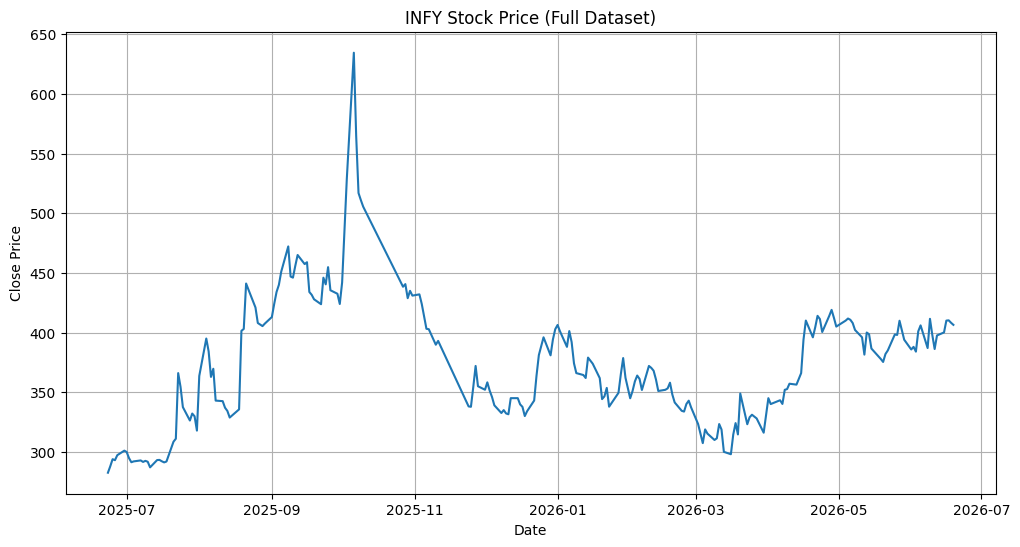


INFY DataFrame Info (Full Dataset):
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 229 entries, 2025-06-23 to 2026-06-19
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   229 non-null    float64
dtypes: float64(1)
memory usage: 3.6 KB

INFY DataFrame Head (Full Dataset):


,Close
DateTime,
2025-06-23,282.50
2025-06-24,287.90
2025-06-25,293.85
2025-06-26,293.00
2025-06-27,297.20


In [ ]:
infy_df = pd.read_csv('/content/infy.csv') # Reload infy_df to ensure 'DateTime' column exists
infy_df['DateTime'] = pd.to_datetime(infy_df['DateTime'])
infy_df.set_index('DateTime', inplace=True)
# Assuming 'KIOCLEQN' is the stock price column based on previous context and `infy_df.info()`
infy_df.rename(columns={'KIOCLEQN': 'Close'}, inplace=True)

# Using the entire dataframe for INFY as it contains approximately 1 year of data
infy_df_filtered = infy_df.copy()

plt.figure(figsize=(12, 6))
plt.plot(infy_df_filtered['Close'])
plt.title('INFY Stock Price (Full Dataset)')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.grid(True)
plt.show()

print('\nINFY DataFrame Info (Full Dataset):')
infy_df_filtered.info()
print('\nINFY DataFrame Head (Full Dataset):')
display(infy_df_filtered.head())

### Preparing Data for GRU Model - INFY

In [ ]:
# Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data_infy = scaler.fit_transform(infy_df_filtered['Close'].values.reshape(-1, 1))

# Create sequences for GRU
def create_sequences(data, time_step):
    X, y = [], []
    for i in range(len(data) - time_step):
        X.append(data[i:(i + time_step), 0])
        y.append(data[i + time_step, 0])
    return np.array(X), np.array(y)

time_step = 60 # Using 60 time steps as common for stock prediction
X_infy, y_infy = create_sequences(scaled_data_infy, time_step)

# Split data into training and testing sets
X_train_infy, X_test_infy, y_train_infy, y_test_infy = train_test_split(X_infy, y_infy, test_size=0.2, random_state=42, shuffle=False)

# Reshape data for GRU input (samples, time_steps, features)
X_train_infy = X_train_infy.reshape(X_train_infy.shape[0], X_train_infy.shape[1], 1)
X_test_infy = X_test_infy.reshape(X_test_infy.shape[0], X_test_infy.shape[1], 1)

print(f'INFY Training features shape: {X_train_infy.shape}')
print(f'INFY Training target shape: {y_train_infy.shape}')
print(f'INFY Testing features shape: {X_test_infy.shape}')
print(f'INFY Testing target shape: {y_test_infy.shape}')

INFY Training features shape: (135, 60, 1)
INFY Training target shape: (135,)
INFY Testing features shape: (34, 60, 1)
INFY Testing target shape: (34,)


### Building and Training GRU Model - INFY

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 501ms/step - loss: 0.0666 - val_loss: 0.0192
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 0.0150 - val_loss: 0.0030
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 0.0240 - val_loss: 0.0017
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 0.0141 - val_loss: 0.0048
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 0.0103 - val_loss: 0.0121
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.0114 - val_loss: 0.0121
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.0097 - val_loss: 0.0067
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 0.0081 - val_loss: 0.0033
Epoch 9/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 0.0083 - val_loss: 0.0022
Epoch 10/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step - loss: 0.0080 - val_loss: 0.0032
Epoch 11/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 0.0070 - val_loss: 0.0050
Epoch 12/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 0.0071 - val_loss: 0.0055
Epoch 13/20

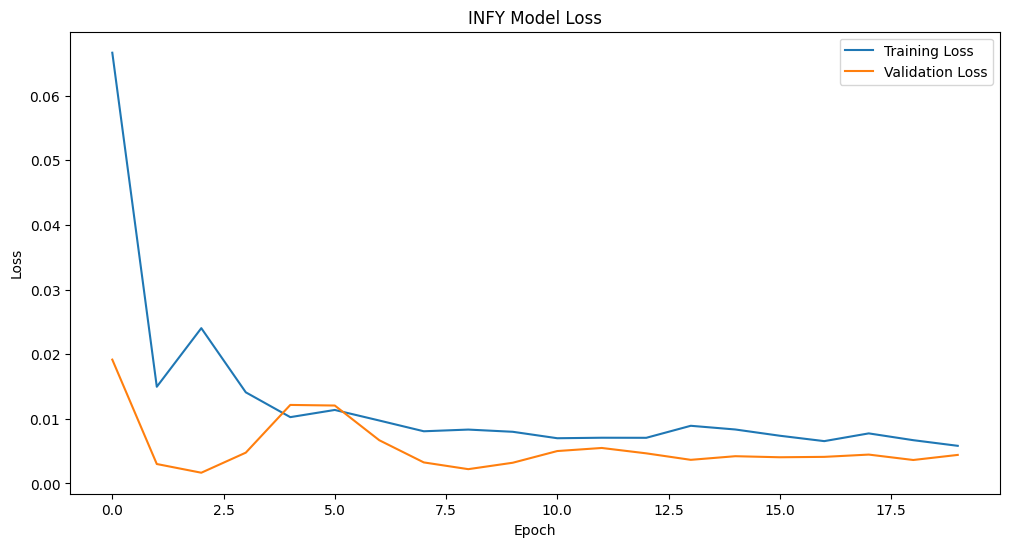

In [ ]:
model_infy = Sequential()
model_infy.add(GRU(units=50, return_sequences=True, input_shape=(time_step, 1)))
model_infy.add(Dropout(0.2))
model_infy.add(GRU(units=50, return_sequences=False))
model_infy.add(Dropout(0.2))
model_infy.add(Dense(units=1))

model_infy.compile(optimizer='adam', loss='mean_squared_error')

history_infy = model_infy.fit(X_train_infy, y_train_infy, epochs=20, batch_size=32, validation_split=0.1, verbose=1)

# Plot training history
plt.figure(figsize=(12, 6))
plt.plot(history_infy.history['loss'], label='Training Loss')
plt.plot(history_infy.history['val_loss'], label='Validation Loss')
plt.title('INFY Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

### Making Predictions - INFY

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 364ms/step
INFY Root Mean Squared Error: 12.49867204464167


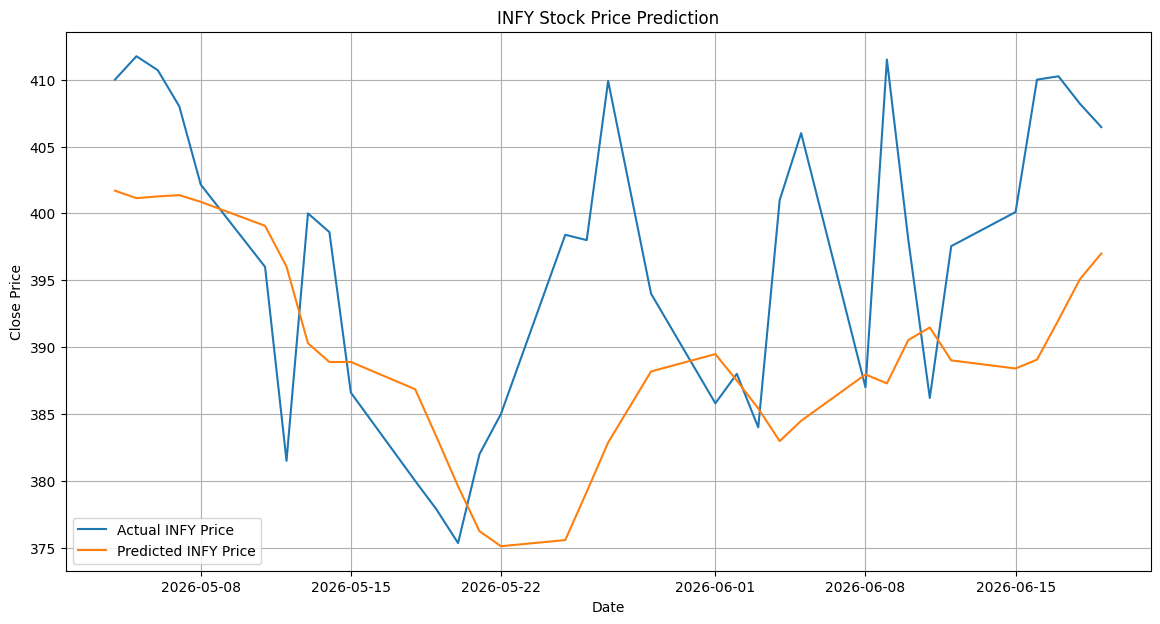

In [ ]:
predictions_infy = model_infy.predict(X_test_infy)
predictions_infy = scaler.inverse_transform(predictions_infy)

# Evaluate the model
rmse_infy = np.sqrt(mean_squared_error(scaler.inverse_transform(y_test_infy.reshape(-1,1)), predictions_infy))
print(f'INFY Root Mean Squared Error: {rmse_infy}')

# Visualize predictions
plt.figure(figsize=(14, 7))
plt.plot(infy_df_filtered.index[-len(y_test_infy):], scaler.inverse_transform(y_test_infy.reshape(-1,1)), label='Actual INFY Price')
plt.plot(infy_df_filtered.index[-len(y_test_infy):], predictions_infy, label='Predicted INFY Price')
plt.title('INFY Stock Price Prediction')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.show()

### Forecasting Next 7 Days for INFY

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step

INFY 7-Day Price Forecast:


,Predicted Close
Date,
2026-06-22,397.759033
2026-06-23,396.163971
2026-06-24,393.879089
2026-06-25,391.447784
2026-06-26,389.040070
2026-06-29,386.704987
2026-06-30,384.453918


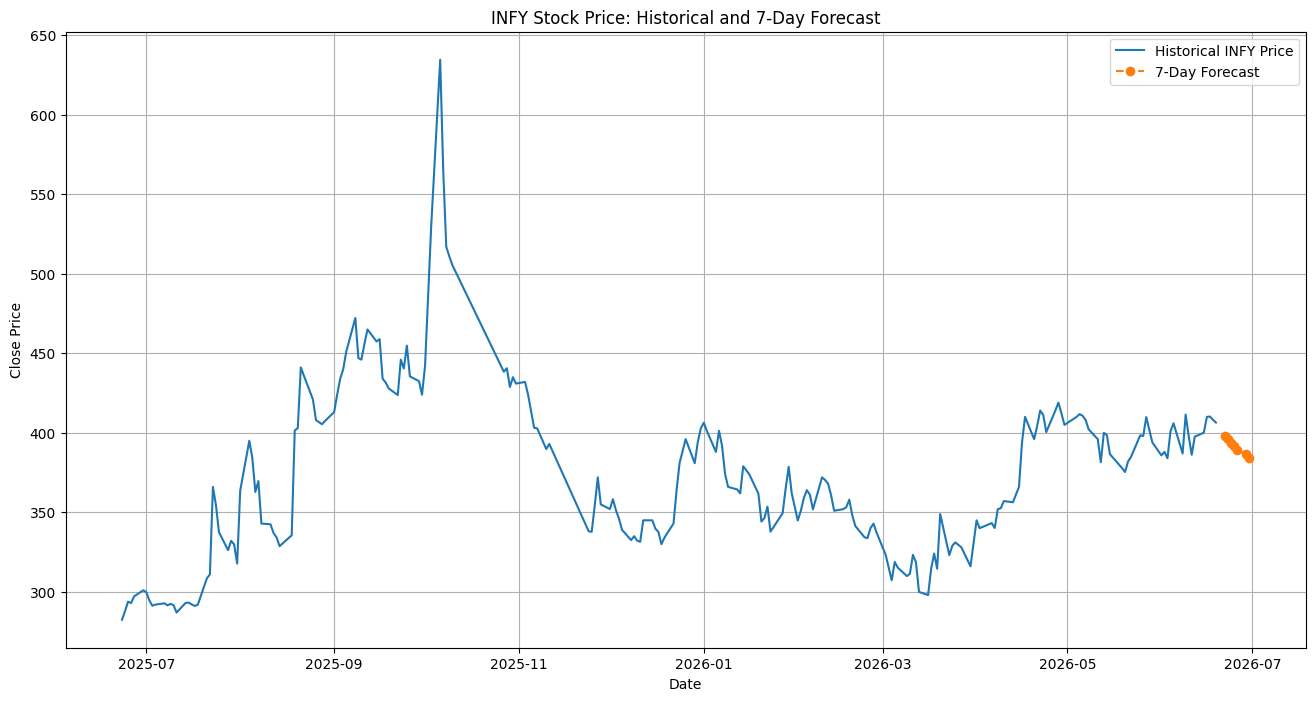

In [ ]:
# Get the last 'time_step' days data from the filtered INFY DataFrame
last_60_days = infy_df_filtered['Close'].values[-time_step:].reshape(-1, 1)

# Scale the last 60 days data using the same scaler fitted on the training data
scaled_last_60_days = scaler.transform(last_60_days)

# Prepare the input for prediction (reshape to GRU input format)
X_predict = scaled_last_60_days.reshape(1, time_step, 1)

# List to store future predictions
future_predictions = []

# Predict the next 7 days
for _ in range(7):
    # Get the prediction for the next day
    next_day_prediction_scaled = model_infy.predict(X_predict)[0, 0]
    future_predictions.append(next_day_prediction_scaled)

    # Update the input sequence for the next prediction
    # Remove the first element and add the new prediction to the end
    X_predict = np.append(X_predict[:, 1:, :], [[[next_day_prediction_scaled]]], axis=1)

# Inverse transform the scaled predictions to get actual prices
future_predictions_actual = scaler.inverse_transform(np.array(future_predictions).reshape(-1, 1))

# Generate future dates
last_date = infy_df_filtered.index[-1]
future_dates = pd.date_range(start=last_date, periods=8, freq='B')[1:] # 'B' for business day

# Create a DataFrame for future predictions
forecast_df = pd.DataFrame({'Date': future_dates, 'Predicted Close': future_predictions_actual.flatten()})
forecast_df.set_index('Date', inplace=True)

print('\nINFY 7-Day Price Forecast:')
display(forecast_df)

# Visualize historical data with future predictions
plt.figure(figsize=(16, 8))
plt.plot(infy_df_filtered.index, infy_df_filtered['Close'], label='Historical INFY Price')
plt.plot(forecast_df.index, forecast_df['Predicted Close'], label='7-Day Forecast', linestyle='--', marker='o')
plt.title('INFY Stock Price: Historical and 7-Day Forecast')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data_infy = scaler.fit_transform(infy_df_filtered['Close'].values.reshape(-1, 1))

# Create sequences for GRU
def create_sequences(data, time_step):
    X, y = [], []
    for i in range(len(data) - time_step):
        X.append(data[i:(i + time_step), 0])
        y.append(data[i + time_step, 0])
    return np.array(X), np.array(y)

time_step = 60 # Using 60 time steps as common for stock prediction
X_infy, y_infy = create_sequences(scaled_data_infy, time_step)

# Split data into training and testing sets
X_train_infy, X_test_infy, y_train_infy, y_test_infy = train_test_split(X_infy, y_infy, test_size=0.2, random_state=42, shuffle=False)

# Reshape data for GRU input (samples, time_steps, features)
X_train_infy = X_train_infy.reshape(X_train_infy.shape[0], X_train_infy.shape[1], 1)
X_test_infy = X_test_infy.reshape(X_test_infy.shape[0], X_test_infy.shape[1], 1)

print(f'INFY Training features shape: {X_train_infy.shape}')
print(f'INFY Training target shape: {y_train_infy.shape}')
print(f'INFY Testing features shape: {X_test_infy.shape}')
print(f'INFY Testing target shape: {y_test_infy.shape}')

INFY Training features shape: (135, 60, 1)
INFY Training target shape: (135,)
INFY Testing features shape: (34, 60, 1)
INFY Testing target shape: (34,)
